In [321]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd

### №1 Выбор датасета

In [234]:
df = pd.read_csv('city_clients.csv')
df = df[df['afisha_first_order_date'].notnull()]
df['afisha_first_order_date'].head()

3     2024-05-10
7     2023-09-13
11    2023-02-21
16    2024-10-08
19    2019-03-07
Name: afisha_first_order_date, dtype: object

In [235]:
new_df = df.groupby('afisha_first_order_date').agg(afisha_count=('afisha_first_order_date', 'count'))
new_df

,afisha_count
afisha_first_order_date,
2017-12-28,4
2018-01-10,1
2018-01-11,1
2018-01-20,1
2018-02-09,1
...,...
2024-10-23,207
2024-10-24,199
2024-10-25,243


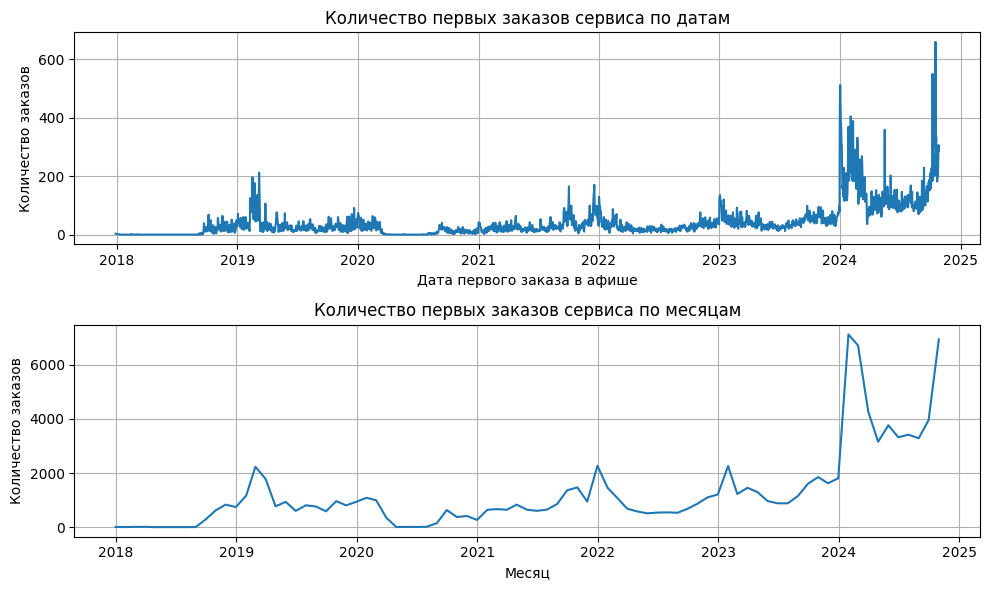

In [236]:
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(pd.to_datetime(new_df.index), new_df['afisha_count'])
plt.xlabel('Дата первого заказа в афише')
plt.ylabel('Количество заказов')
plt.title('Количество первых заказов сервиса по датам')
plt.grid(True)
plt.tight_layout()
new_df['date'] = pd.to_datetime(new_df.index)
monthly_data = new_df.resample('ME', on='date')['afisha_count'].sum()
plt.subplot(2, 1, 2)
plt.plot(monthly_data.index, monthly_data)
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.title('Количество первых заказов сервиса по месяцам')
plt.grid(True)
plt.tight_layout()
plt.show()

### №2 Исследование ряда 

In [237]:
import statsmodels.api as sm
p = sm.tsa.stattools.adfuller(new_df['afisha_count'])[1]
print(f'Критерий Дики-Фуллера: p-value={p}')

Критерий Дики-Фуллера: p-value=0.6947749915569328


p-value > 0.05, значит, у нас недостаточно свидетельств о том, что ряд стационарен. Значит, имеет место тренд/сезонность/изменения дисперсии.

In [238]:
time = np.arange(len(new_df['afisha_count']))
t, p = stats.kendalltau(time, new_df['afisha_count'])
print(f"Тест Манна-Кендалла p-value: {p:.6f}")

Тест Манна-Кендалла p-value: 0.000000


С помощью теста Манна-Кендалла мы получили, что p_value < 0.05 и t > 0, а это значит, что у нас есть основания предполагать, что есть монотонно высходящий тренд, и матожидание растёт. Значит, чтобы корректно определить сезонность, нужно сначала избавиться от тренда (можно, например, удалить тренд с помощью дифференцирования)

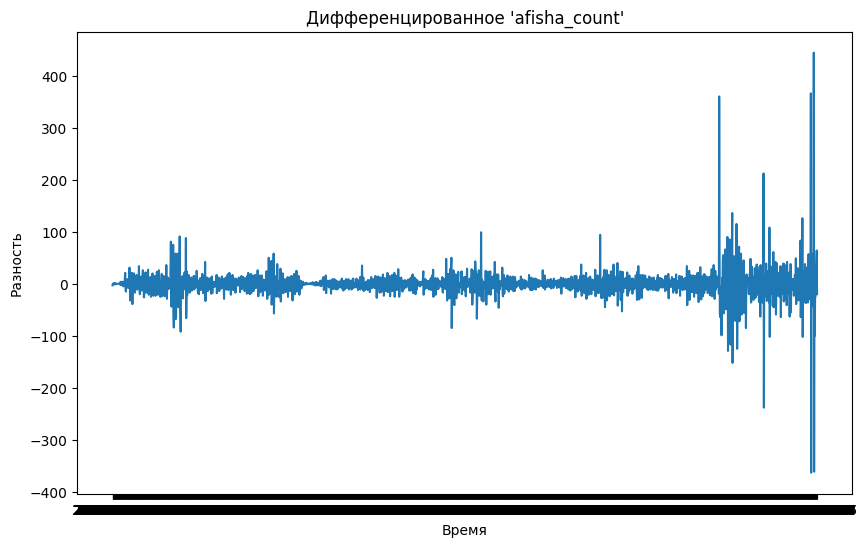

In [239]:
diff = new_df['afisha_count'].diff(1).dropna()
plt.figure(figsize=(10, 6))
plt.plot(diff)
plt.title("Дифференцированное 'afisha_count'")
plt.xlabel("Время")
plt.ylabel("Разность")
plt.show()

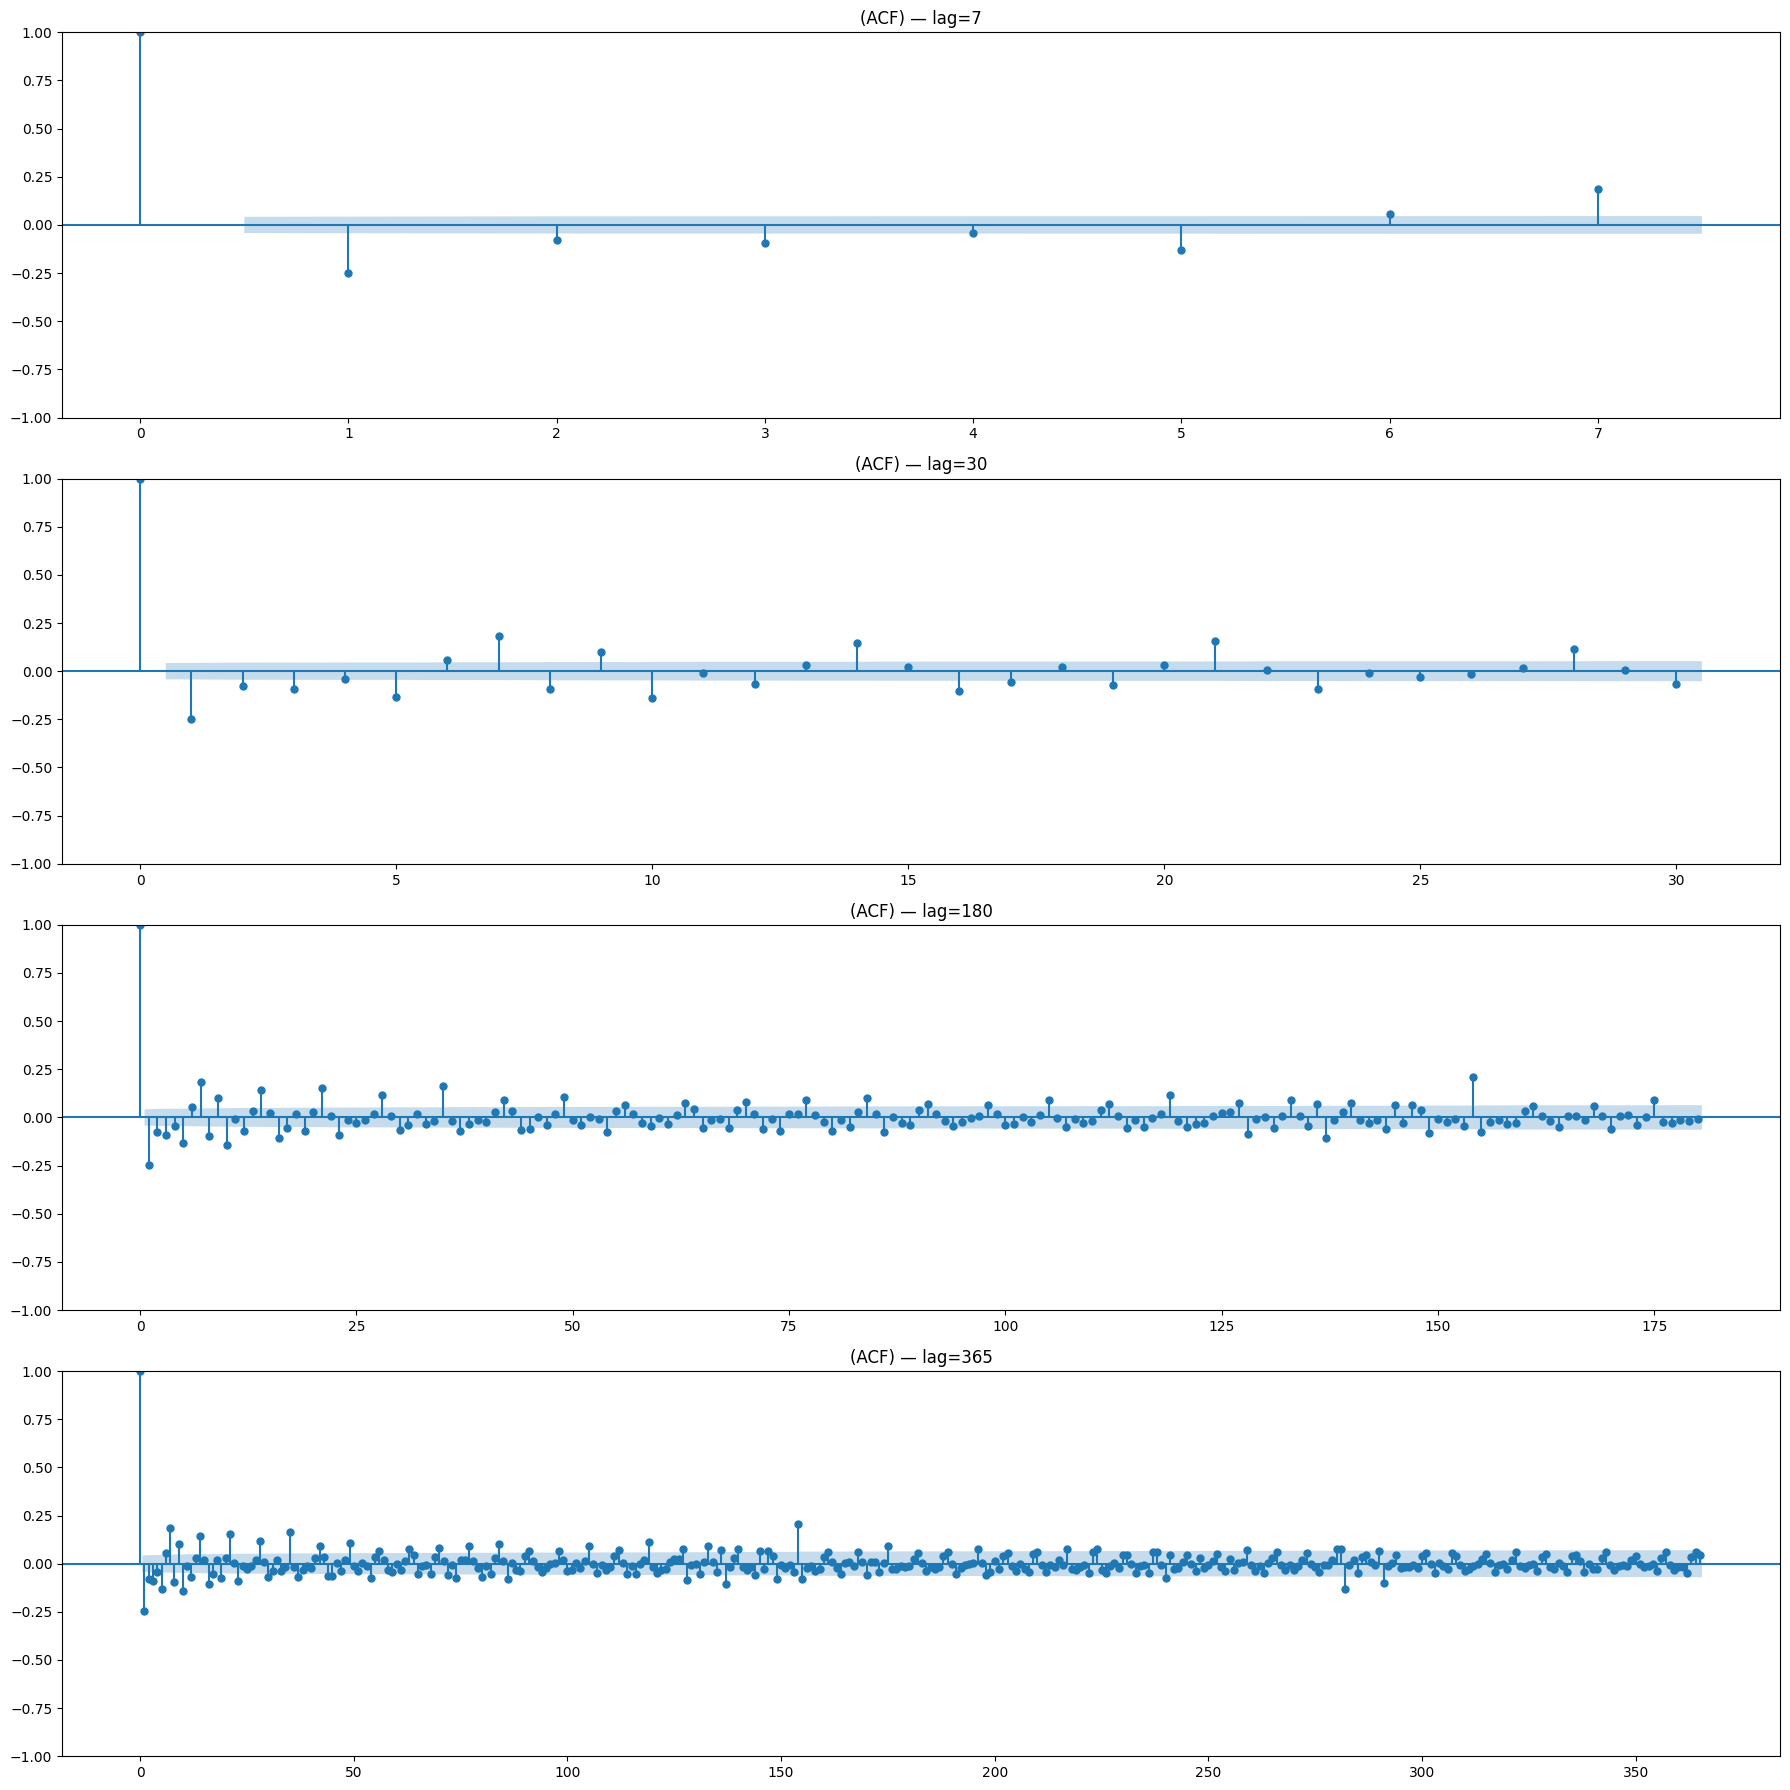

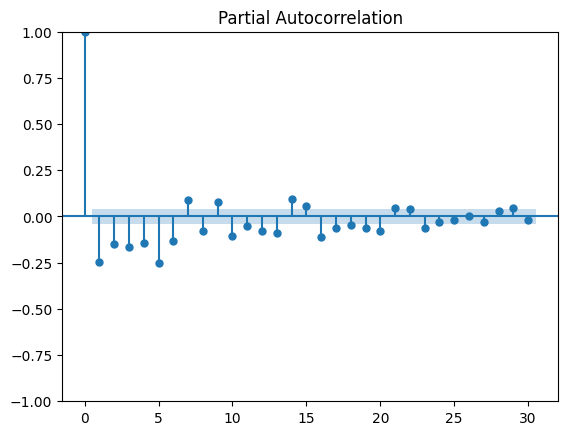

In [240]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(18, 18))

plot_acf(diff, lags=7, ax=ax1)
plot_acf(diff, lags=30, ax=ax2)
plot_acf(diff, lags=180, ax=ax3)
plot_acf(diff, lags=365, ax=ax4)

ax1.set_title('(ACF) — lag=7')
ax2.set_title('(ACF) — lag=30')
ax3.set_title('(ACF) — lag=180')
ax4.set_title('(ACF) — lag=365')

plt.tight_layout()
plt.show()

plot_pacf(diff, lags=30)
plt.show()

Мы видим, что есть недельная сезонность. 

И, подводя итоги, нужно сказать, что у ряда есть и сезонность (7 дней), и тренд (вверх)


### №3 Превращение ряда в стационарный
Далее нужно было попытаться сделать ряд стационарным, чтобы избавиться от тренда, мы уже применяли дифференцирование. Теперь можно также применить логарифмирование, чтобы стабилизировать дисперсию, а затем diff(7), чтобы убрать сезонность.

In [241]:
log_series = np.log(new_df['afisha_count'])
p = sm.tsa.stattools.adfuller(log_series)[1]
print(f'Критерий Дики-Фуллера логарифмированного ряда: p-value={p:.10f}')
t, p = stats.kendalltau(time, log_series)
print(f"Тест Манна-Кендалла логарифмированного ряда p-value: {p:.10f}")


Критерий Дики-Фуллера логарифмированного ряда: p-value=0.0064892121
Тест Манна-Кендалла логарифмированного ряда p-value: 0.0000000000


После логарифмирования ряд уже стал статистически значимо стационарным по тесту Дикки-Фуллера, но тренд всё ещё остался. Нужно что-то с этим сделать,, например, дифференцирование.

После log().diff(1) на тесте Дики-Фуллера: p-value = 0.0000000000


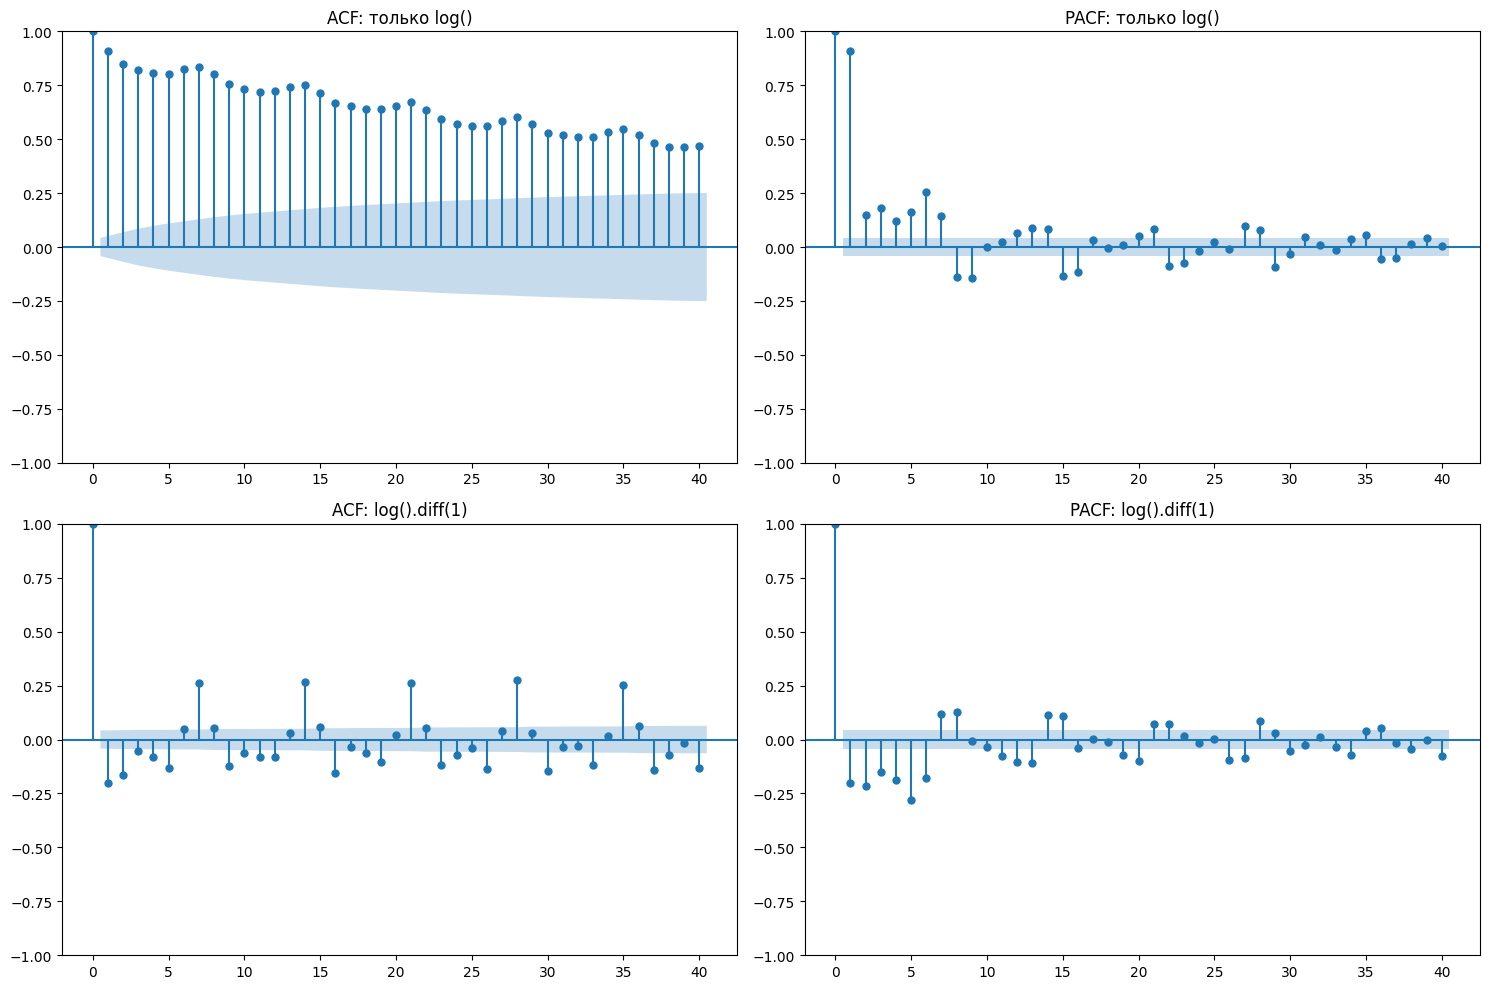

In [242]:
log_diff_series = log_series.diff(1).dropna()
p_final = sm.tsa.stattools.adfuller(log_diff_series)[1]
print(f"После log().diff(1) на тесте Дики-Фуллера: p-value = {p_final:.10f}")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

plot_acf(log_series, lags=40, ax=axes[0, 0], title='ACF: только log()')
plot_pacf(log_series, lags=40, ax=axes[0, 1], title='PACF: только log()')

plot_acf(log_diff_series, lags=40, ax=axes[1, 0], title='ACF: log().diff(1)')
plot_pacf(log_diff_series, lags=40, ax=axes[1, 1], title='PACF: log().diff(1)')

plt.tight_layout()
plt.show()

In [243]:
acf_values = sm.tsa.stattools.acf(log_diff_series, nlags=21)
print(f"Сезонность 7 дней: ACF = {acf_values[7]:.3f}")

Сезонность 7 дней: ACF = 0.261


Мы избавились от тренда и стабилизировали дисперсию, теперь нужно избавиться от сезонности и ряд будет стационарным.

После log().diff(7).diff(1) на тесте Дика-Фуллера: p-value=0.0000000000


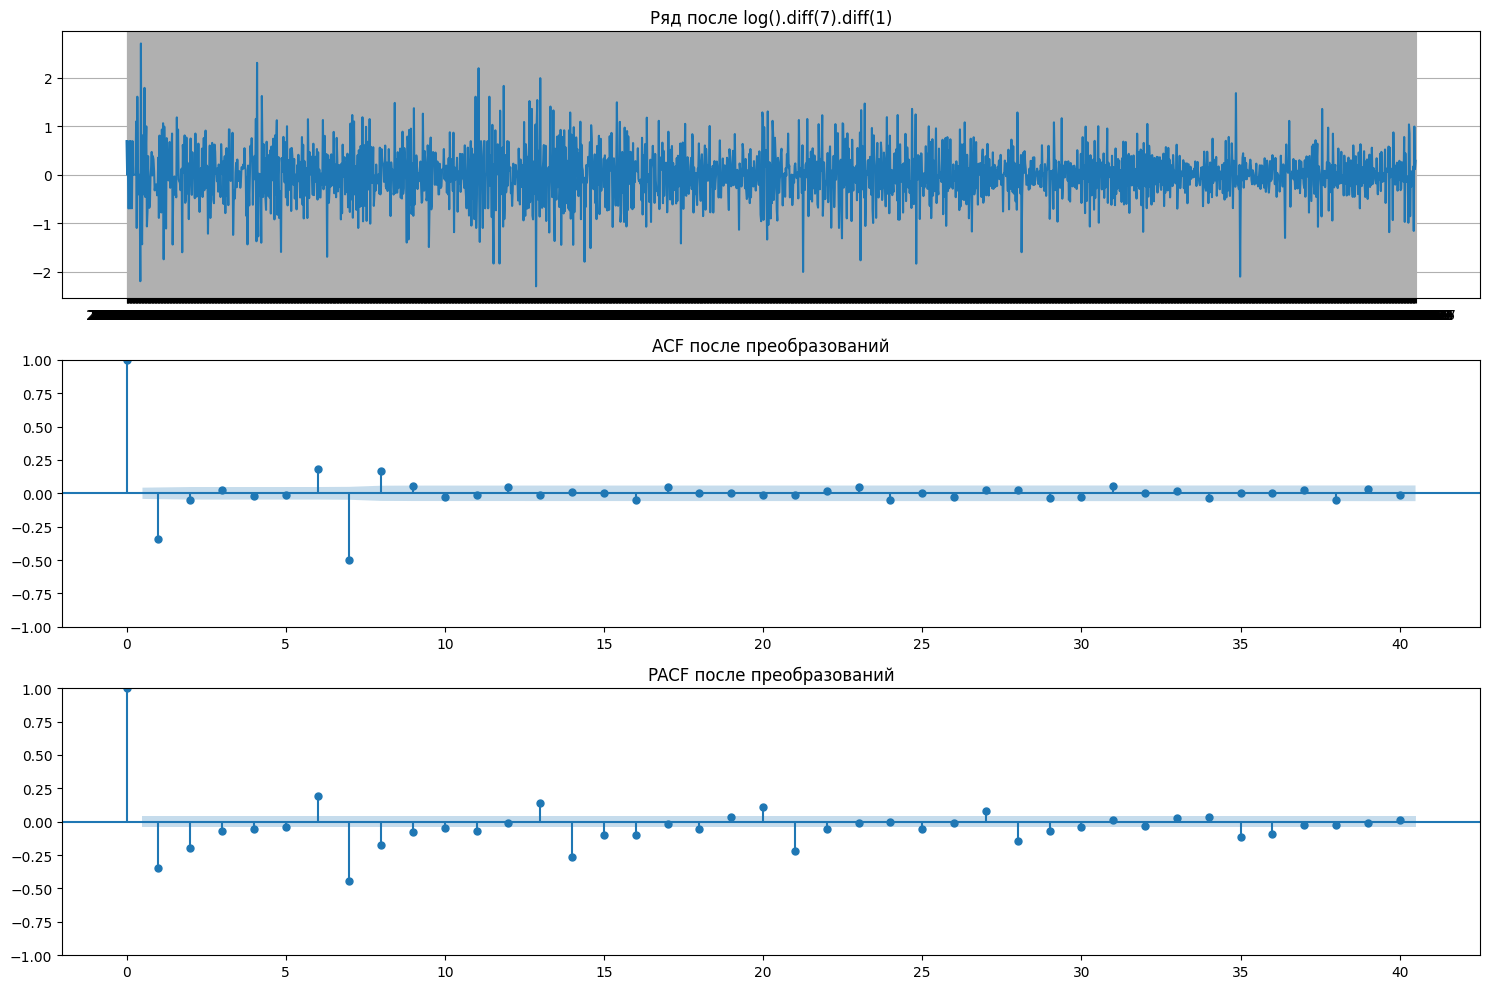

ACF значения на сезонных лагах:
Лаг 7: -0.502
Лаг 14: 0.008
Лаг 21: -0.014


In [244]:
seasonal_first = log_series.diff(7).dropna()
final_series = seasonal_first.diff(1).dropna()
p_final = sm.tsa.stattools.adfuller(final_series)[1]
print(f'После log().diff(7).diff(1) на тесте Дика-Фуллера: p-value={p_final:.10f}')
fig, axes = plt.subplots(3, 1, figsize=(15, 10))
axes[0].plot(final_series)
axes[0].set_title('Ряд после log().diff(7).diff(1)')
axes[0].grid(True)

plot_acf(final_series, lags=40, ax=axes[1])
axes[1].set_title('ACF после преобразований')

plot_pacf(final_series, lags=40, ax=axes[2])
axes[2].set_title('PACF после преобразований')

acf_final = sm.tsa.stattools.acf(final_series, nlags=21)

plt.tight_layout()
plt.show()

print("ACF значения на сезонных лагах:")
for lag in range(7, 22, 7):
    if lag < len(acf_final):
        print(f"Лаг {lag}: {acf_final[lag]:.3f}")

Всё ещё очень сильная сезонность (высокая корреляция на лаге 7)

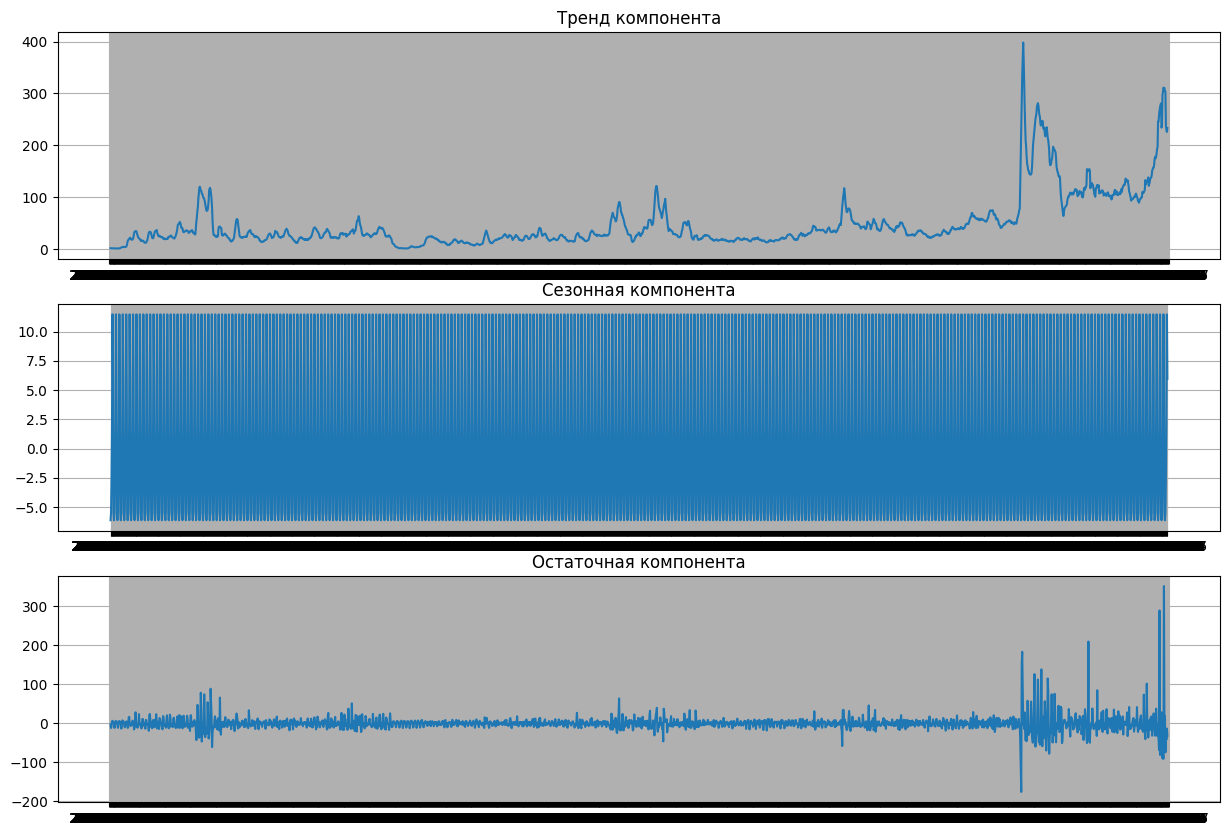

In [245]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(new_df['afisha_count'], model='additive', period=7)

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

axes[0].plot(decomposition.trend)
axes[0].set_title('Тренд компонента')
axes[0].grid(True)

axes[1].plot(decomposition.seasonal)
axes[1].set_title('Сезонная компонента')
axes[1].grid(True)

axes[2].plot(decomposition.resid)
axes[2].set_title('Остаточная компонента')
axes[2].grid(True)

plt.show()

### №4 Обучение моделей линейной регрессии

In [246]:
pi = np.pi

new_df['date'] = pd.to_datetime(new_df.index)
new_df['day_of_year'] = new_df['date'].dt.dayofyear
new_df['day_of_week'] = new_df['date'].dt.dayofweek
new_df['day_of_month'] = new_df['date'].dt.day
new_df['month'] = new_df['date'].dt.month
new_df['is_weekend'] = (new_df['date'].dt.dayofweek >= 5).astype(int)

new_df['day_of_year_sin'] = np.sin(2 * pi * new_df['day_of_year'] / 365)
new_df['day_of_year_cos'] = np.cos(2 * pi * new_df['day_of_year'] / 365)
new_df['day_of_week_sin'] = np.sin(2 * pi * new_df['day_of_week'] / 7)
new_df['day_of_week_cos'] = np.cos(2 * pi * new_df['day_of_week'] / 7)
new_df['month_sin'] = np.sin(2 * pi * new_df['month'] / 12)
new_df['month_cos'] = np.cos(2 * pi * new_df['month'] / 12)

new_df['lag_1'] = new_df['afisha_count'].shift(1)
new_df['lag_7'] = new_df['afisha_count'].shift(7)
new_df['lag_30'] = new_df['afisha_count'].shift(30)

new_df['mean_7'] = new_df['afisha_count'].rolling(window=7).mean()
new_df['std_7'] = new_df['afisha_count'].rolling(window=7).std()

In [271]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

df_clean = new_df.dropna().copy()
df_clean['stationary_series'] = np.log(df_clean['afisha_count']).diff(1)
df_stationary = df_clean.dropna().copy()

feature_columns = df_stationary.columns.difference([
    'afisha_count', 'date', 'day_name', 'quarter', 
    'rolling_mean_7', 'rolling_std_7', 'target', 
    'week_of_year', 'stationary_series'
])

X = df_stationary[feature_columns]
y = df_stationary['stationary_series']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False, random_state=58)


In [272]:

def get_result(model):
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = model.score(X_test, y_test)

    print(f"MSE: {mse:.4f}") 
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")

    return y_pred



In [273]:
from sklearn.linear_model import SGDRegressor
model = SGDRegressor()
model.fit(X_train, y_train)
res = get_result(model)

MSE: 1636454485595337314692759552.0000
RMSE: 40453114658766.8516
R2: -19735063340068223517246619648.0000


In [274]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=100)
model.fit(X_train, y_train)
y_pred = get_result(model)

MSE: 0.0839
RMSE: 0.2897
R2: -0.0123


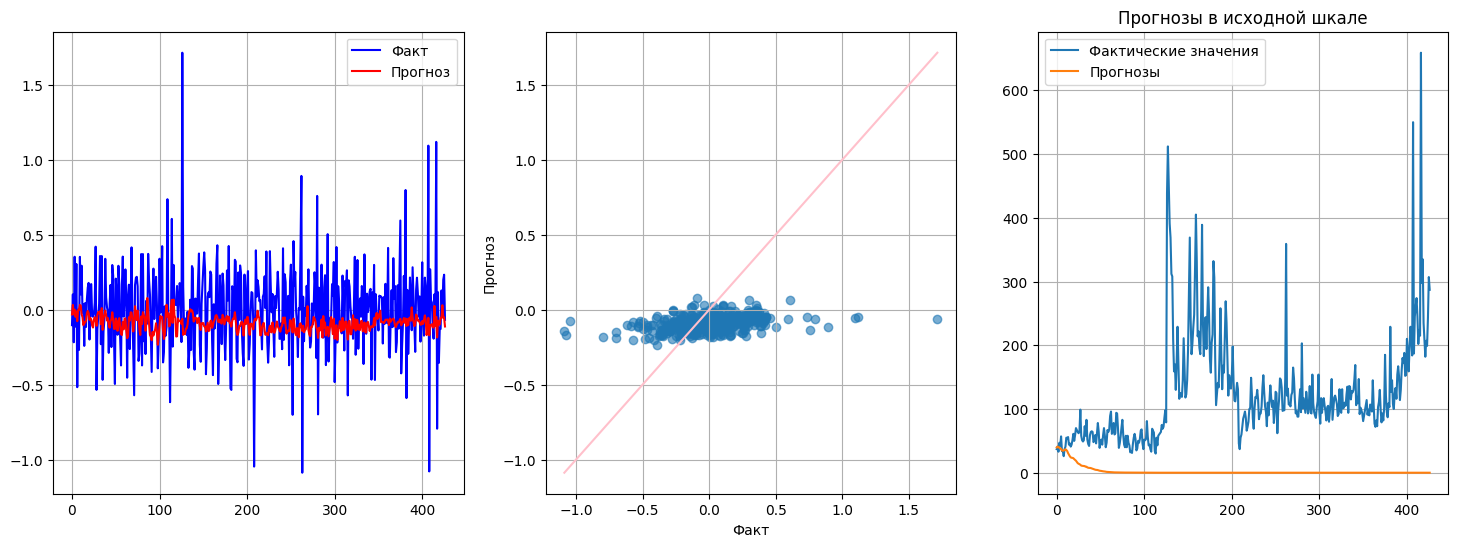

<Figure size 640x480 with 0 Axes>

In [275]:
split_idx = int(0.8 * len(df_stationary))
last_train_value = np.log(df_stationary['afisha_count'].iloc[split_idx-1])
log_actual = last_train_value + np.cumsum(y_test.values)
y_test_original = np.exp(log_actual)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(y_test.values, label='Факт', color='blue')
plt.plot(y_pred, label='Прогноз', color='red')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'pink')
plt.xlabel('Факт')
plt.ylabel('Прогноз')
plt.grid(True)

split_idx = int(0.8 * len(df_stationary))
last_train_value = np.log(df_stationary['afisha_count'].iloc[split_idx-1])
log_predictions = last_train_value + np.cumsum(y_pred)
log_actual = last_train_value + np.cumsum(y_test.values)
y_pred_original = np.exp(log_predictions)
y_test_original = np.exp(log_actual)
plt.subplot(1, 3, 3)
plt.plot(y_test_original, label='Фактические значения')
plt.plot(y_pred_original, label='Прогнозы')
plt.title('Прогнозы в исходной шкале')
plt.legend()
plt.grid(True)
plt.show()

plt.tight_layout()
plt.show()

In [267]:
new_df = new_df.dropna()
X = new_df[feature_columns]
y = new_df['afisha_count']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False, random_state=589)
model = KNeighborsRegressor(n_neighbors=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = model.score(X_test, y_test)

print(f"MSE: {mse:.4f}") 
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

MSE: 10470.9622
RMSE: 102.3277
R2: -0.5206


### №5 Обучение моделей для временных рядов

In [337]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

y = new_df['afisha_count'].dropna()
dates = pd.DatetimeIndex(new_df.index)

size = len(y) // 4
y_train, y_test, dates_train, dates_test = train_test_split(y.iloc[:size], dates[:size], test_size=0.2, shuffle=False, random_state=12)

y_train = pd.Series(y_train.values, index=dates_train)
y_test = pd.Series(y_test.values, index=dates_test)
y_train = y_train.asfreq('D')
y_test = y_test.asfreq('D')


SARIMA RMSE: 14.09


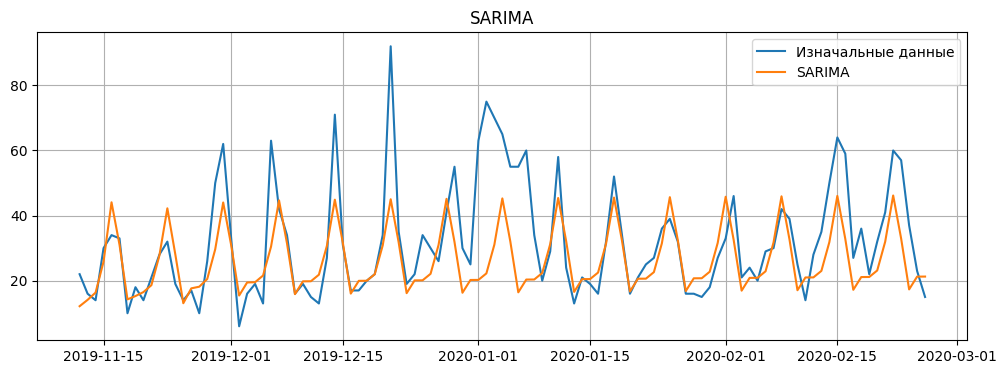

In [338]:

sarima_model = SARIMAX(y_train, order=(1,1,1), seasonal_order=(0,1,3,7))
sarima_fit = sarima_model.fit(disp=False)
sarima_predictions = sarima_fit.forecast(steps=len(y_test))
sarima_train_predictions = sarima_fit.fittedvalues

sarima_rmse = np.sqrt(mean_squared_error(y_test, sarima_predictions))

print(f"SARIMA RMSE: {sarima_rmse:.2f}")

plt.figure(figsize=(12, 4))
plt.plot(y_test.index, y_test.values, label='Изначальные данные')
plt.plot(y_test.index, sarima_predictions, label='SARIMA')
plt.legend()
plt.title('SARIMA')
plt.grid(True)
plt.show()

Модель Хольта-Уинтерса, RMSE: 16.35


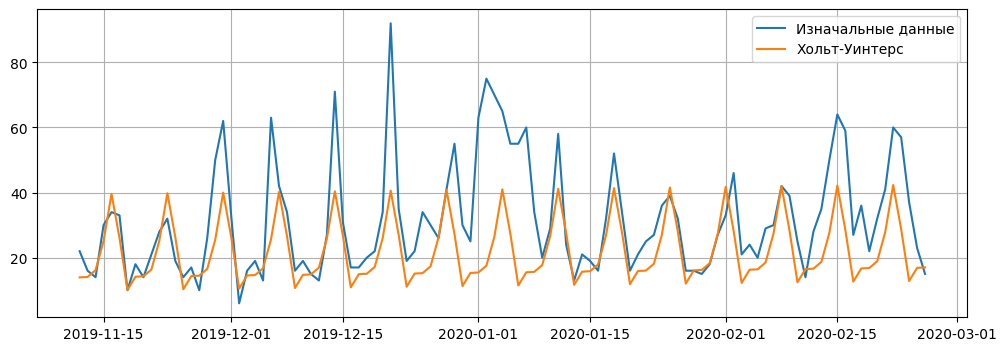

In [339]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(y_train, seasonal='add', seasonal_periods=7, trend='add')
hw_fit = hw_model.fit()
hw_predictions = hw_fit.forecast(len(y_test))
hw_train_predictions = hw_fit.fittedvalues

hw_rmse = np.sqrt(mean_squared_error(y_test, hw_predictions))

print(f"Модель Хольта-Уинтерса, RMSE: {hw_rmse:.2f}")

plt.figure(figsize=(12, 4))
plt.plot(y_test.index, y_test.values, label='Изначальные данные')
plt.plot(y_test.index, hw_predictions, label='Хольт-Уинтерс')
plt.legend()
plt.grid(True)
plt.show()

In [340]:
mean_value = y_test.mean()
std_value = y_test.std()

print(f"Среднее значение: {mean_value:.2f}")
print(f"Стандартное отклонение: {std_value:.2f}") 

print("---SARIMA---")
print(f"RMSE: {sarima_rmse:.2f}")
print(f"RMSE/Mean: {sarima_rmse/mean_value*100:.2f}%")
print(f"RMSE/Std: {sarima_rmse/std_value*100:.2f}%")

print("---Хольт-Уинтерс---")
print(f"RMSE: {hw_rmse:.2f}")
print(f"RMSE/Mean: {hw_rmse/mean_value*100:.2f}%")
print(f"RMSE/Std: {hw_rmse/std_value*100:.2f}%")

Среднее значение: 31.77
Стандартное отклонение: 17.06
---SARIMA---
RMSE: 14.09
RMSE/Mean: 44.36%
RMSE/Std: 82.61%
---Хольт-Уинтерс---
RMSE: 16.35
RMSE/Mean: 51.46%
RMSE/Std: 95.84%


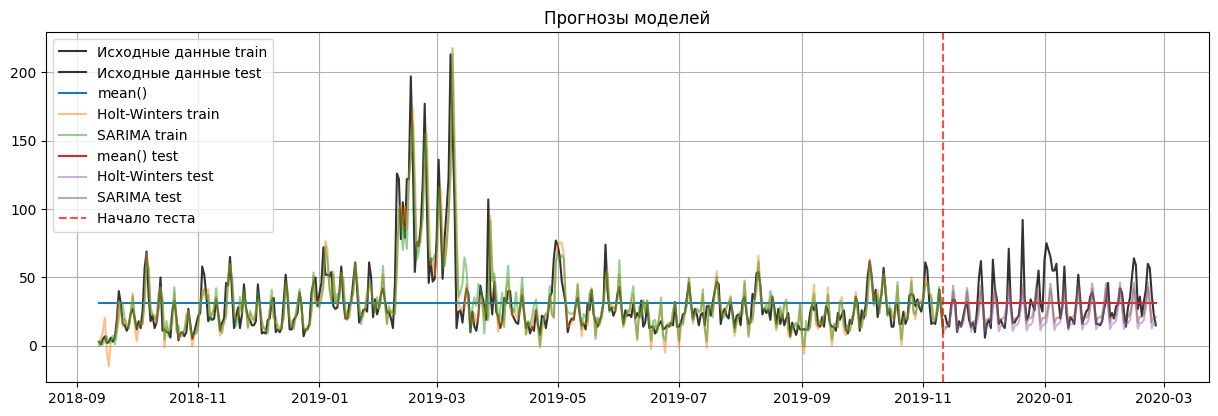

In [348]:
plt.figure(figsize=(15, 10))

native = y_train.mean()
native_train_pred = np.full(len(y_train), native)
native_predictions = np.full(len(y_test), native)

plt.subplot(2, 1, 1)
plt.plot(y_train.index, y_train.values, label='Исходные данные train', color='black', alpha=0.8)
plt.plot(y_test.index, y_test.values, label='Исходные данные test', color='black', alpha=0.8)
plt.plot(y_train.index, native_train_pred, label='mean()')
plt.plot(y_train.index, hw_train_predictions, label='Holt-Winters train', alpha=0.5)
plt.plot(y_train.index, sarima_train_predictions, label='SARIMA train', alpha=0.5)
plt.plot(y_test.index, native_predictions, label='mean() test')
plt.plot(y_test.index, hw_predictions, label='Holt-Winters test', alpha=0.5)
plt.plot(y_test.index, sarima_predictions, label='SARIMA test', alpha=0.5)
plt.axvline(x=y_train.index[-1], color='red', linestyle='--', alpha=0.7, label='Начало теста')
plt.legend()
plt.title('Прогнозы моделей')
plt.grid(True)

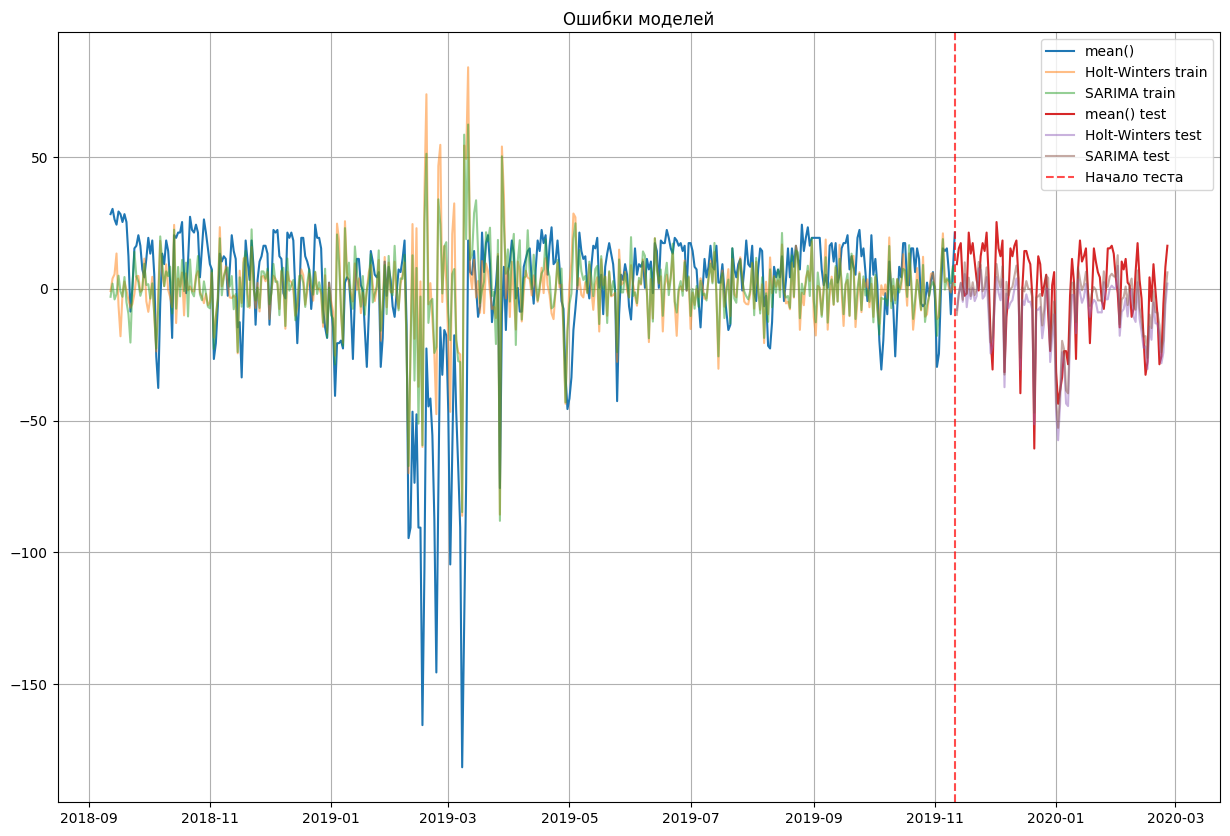

In [349]:
plt.figure(figsize=(15, 10))

native = y_train.mean()
native_train_pred = np.full(len(y_train), native)
native_predictions = np.full(len(y_test), native)

plt.plot(y_train.index, native_train_pred - y_train.values, label='mean()')
plt.plot(y_train.index, hw_train_predictions - y_train.values, label='Holt-Winters train', alpha=0.5)
plt.plot(y_train.index, sarima_train_predictions - y_train.values, label='SARIMA train', alpha=0.5)
plt.plot(y_test.index, native_predictions - y_test.values, label='mean() test')
plt.plot(y_test.index, hw_predictions - y_test.values, label='Holt-Winters test', alpha=0.5)
plt.plot(y_test.index, sarima_predictions - y_test.values, label='SARIMA test', alpha=0.5)
plt.axvline(x=y_train.index[-1], color='red', linestyle='--', alpha=0.7, label='Начало теста')
plt.legend()
plt.title('Ошибки моделей')
plt.grid(True)